In [ ]:
from google.colab import files
files.upload()

# Cấu hình credentials
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

Saving kaggle.json to kaggle.json


In [ ]:
!pip install kaggle -q

!kaggle datasets download -d blacknguyen119/dataset-fall

!unzip -q dataset-fall.zip -d /content/dataset-fall

Dataset URL: https://www.kaggle.com/datasets/blacknguyen119/dataset-fall
License(s): unknown
100% 15.0G/15.0G [02:52<00:00, 93.2MB/s]



Extract frames

In [ ]:
from multiprocessing import Pool
import os
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm

def process_single_video(args):
    video_path, output_root, num_frames = args
    video_path = Path(video_path)

    cls   = video_path.parent.parent.name
    split = video_path.parent.parent.parent.name
    video_id   = video_path.stem
    output_dir = Path(output_root) / split / cls / video_id

    # Bỏ qua nếu đã extract rồi
    if (output_dir / 'frames.npy').exists():
        return f"Skip: {video_id}"

    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames >= num_frames:
        indices = set(np.linspace(0, total_frames - 1, num_frames, dtype=int))
    else:
        indices = set(range(total_frames))

    # Đọc tuần tự thay vì seek từng frame (nhanh hơn 2-5x)
    frames_dict = {}
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (288, 288), interpolation=cv2.INTER_LINEAR)
            frames_dict[frame_idx] = frame
        frame_idx += 1

    cap.release()

    # Sắp xếp đúng thứ tự
    frames = [frames_dict[i] for i in sorted(frames_dict.keys())]

    # Padding nếu video ngắn hơn num_frames
    while len(frames) < num_frames:
        frames.append(frames[-1])

    np.save(output_dir / 'frames.npy', np.array(frames, dtype=np.uint8))
    return f"Done: {video_id}"


def extract_and_save_frames_fast(dataset_root, output_root, num_frames=32):
    dataset_root = Path(dataset_root)

    all_videos = []
    for split in ['train', 'val', 'test']:
        for cls in ['Fall', 'No_Fall']:
            video_dir = dataset_root / split / cls / 'Raw_Video'
            if not video_dir.exists():
                continue
            videos = [v for v in video_dir.glob('*.mp4') if 'resized' not in v.name]
            all_videos.extend(videos)

    print(f"Tổng số video: {len(all_videos)}")

    # Đếm số video cần skip và cần xử lý
    need_process = [v for v in all_videos
                    if not (Path(output_root) / v.parent.parent.parent.name
                            / v.parent.parent.name / v.stem / 'frames.npy').exists()]
    print(f"Đã extract: {len(all_videos) - len(need_process)} | Còn lại: {len(need_process)}")

    if not need_process:
        print("Tất cả đã được extract!")
        return

    args = [(str(v), output_root, num_frames) for v in need_process]

    with Pool(4) as pool:
        for _ in tqdm(pool.imap_unordered(process_single_video, args),
                      total=len(args), desc="Extracting"):
            pass

    print("Hoàn thành!")


extract_and_save_frames_fast(
    dataset_root='/content/dataset-fall/split_dataset',
    output_root='frames_extracted',  # (Drive)
    num_frames=32
)

Tổng số video: 4603
Đã extract: 0 | Còn lại: 4603


Extracting: 100%|██████████| 4603/4603 [1:14:06<00:00,  1.04it/s]

Hoàn thành!


In [ ]:
"""
for video_path in tqdm(videos, desc=f"{split}/{cls}"):
    video_id = video_path.stem
    output_dir = output_root / split / cls / video_id

    # Thêm dòng này: nếu đã extract rồi thì bỏ qua
    if (output_dir / 'frames.npy').exists():
        continue

    output_dir.mkdir(parents=True, exist_ok=True)
# ... phần còn lại giữ nguyên
"""

In [ ]:
'''
from pathlib import Path

output_root = Path('frames_extracted')
total = sum(1 for f in output_root.rglob('frames.npy'))
print(f"Đã extract: {total} videos")

'''

In [ ]:
import os
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import pickle

In [ ]:
def extract_frame(video_input, num_frames):
    #Trích xuất num_frames từ video
    try:
      cap = cv2.VideoCapture(video_input)
      total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
      frames = []
      if total_frames >= num_frames:
          index_frames = np.linspace(0, total_frames - 1, num_frames, dtype=int)
      else:
          index_frame = np.arange(0, total_frames)
          #Lặp lại frame cuối
          index_frame_lack = np.full(num_frames - total_frames, index_frame[-1])
          index_frames = np.concatenate((index_frame, index_frame_lack))
      for index_frame in index_frames:
          cap.set(cv2.CAP_PROP_POS_FRAMES, index_frame)
          ret, frame = cap.read()
          if ret:
              frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
              # frame_resize = cv2.resize(frame, (img_size, img_size))
              frames.append(frame)
      return np.array(frames)
    finally:
      cap.release()

In [ ]:
import os
os.cpu_count()

2

In [ ]:
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [ ]:
train_path = '/content/dataset-fall/split_dataset/train'
classes = ['Fall', 'No_Fall']
for cls in classes:
    train_cls_path = os.path.join(train_path, cls, 'Raw_Video')
    number_video_cls_in_train = len(os.listdir(train_cls_path))
    print(f"{cls}: co {number_video_cls_in_train} video")

Fall: co 2512 video
No_Fall: co 3078 video


In [ ]:
count_video_each_cls = []
for cls in classes:
    count_video_no_resized = 0
    train_cls_path = os.path.join(train_path, cls, 'Raw_Video')
    for video_name in os.listdir(train_cls_path):
        if re.search('resized', video_name) is None:
            count_video_no_resized += 1
    count_video_each_cls.append(count_video_no_resized)
    print(f'{cls} co {count_video_no_resized} satisfied')

Fall co 1654 satisfied
No_Fall co 2026 satisfied


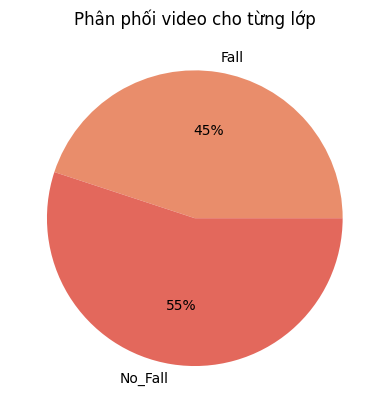

In [ ]:
labels = ['Fall', 'No_Fall']
colors = sns.color_palette('flare')

plt.pie(count_video_each_cls, labels = labels, colors = colors, autopct = '%0.f%%')
plt.title('Phân phối video cho từng lớp')
plt.show()

In [ ]:
!pip -q install albumentations

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs("/content/drive/MyDrive/fall_detection", exist_ok=True)


Mounted at /content/drive


In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_FRAMES = 16
BATCH_SIZE = 8
NUM_WORKERS = max(0, os.cpu_count() - 2)  # Đảm bảo không âm (vì train trên colab free nên chỉ đc cấp 2 cpu_count)

In [ ]:
train_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    # A.RandomCrop(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit = 15, p = 0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2),
    A.GaussNoise(p=0.2),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    A.ToTensorV2()
])
val_test_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    A.ToTensorV2()
])

In [ ]:
class FallDetectionDatasetPreExtracted(Dataset):
    def __init__(self, frames_root, split, transform):
        self.frames_root = Path(frames_root) / split
        self.transform = transform

        self.frame_paths = []
        self.labels = []

        for cls_idx, cls in enumerate(['Fall', 'No_Fall']):
            cls_dir = self.frames_root / cls
            if cls_dir.exists():
                for video_dir in cls_dir.iterdir():
                    frame_file = video_dir / 'frames.npy'
                    if frame_file.exists():
                        self.frame_paths.append(frame_file)
                        self.labels.append(1 if cls == 'Fall' else 0)

    def __len__(self):
        return len(self.frame_paths)

    def __getitem__(self, idx):
        # Load frames
        frames = np.load(self.frame_paths[idx])
        label = self.labels[idx]

        # Apply transform
        augmented_frames = self.transform(images=frames)['images']

        return augmented_frames, label

In [ ]:
train_dataset = FallDetectionDatasetPreExtracted(
    frames_root='/content/frames_extracted',
    split='train',
    transform=train_transform
)

val_dataset = FallDetectionDatasetPreExtracted(
    frames_root='/content/frames_extracted',
    split='val',
    transform=val_test_transform
)


test_dataset = FallDetectionDatasetPreExtracted(
    frames_root='/content/frames_extracted',
    split='test',
    transform=val_test_transform
)

In [ ]:
len(train_dataset), len(val_dataset)

(3680, 474)

In [ ]:
import torch
PIN_MEMORY = True if torch.cuda.is_available() else False
print(f"GPU available: {torch.cuda.is_available()} | PIN_MEMORY: {PIN_MEMORY}")

GPU available: True | PIN_MEMORY: True


In [ ]:
# dataloader
NUM_WORKERS = 0

train_batch = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)
val_batch = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)
test_batch = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)

In [ ]:
batch = next(iter(train_batch))     # lấy 1 batch
if isinstance(batch, (list, tuple)):
    images, targets = batch
else:
    images = batch

print("images:", images.shape)       # ví dụ: torch.Size([B, C, H, W])
print("targets:", getattr(targets, "shape", None))

images: torch.Size([8, 32, 3, 224, 224])
targets: torch.Size([8])


In [ ]:
import torch.nn as nn
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

class EfficientNetLSTM(nn.Module):
    def __init__(self, hidden_size=256, num_layers=2, dropout=0.5):
        super(EfficientNetLSTM, self).__init__()

        weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
        self.efficientnet = efficientnet_v2_s(weights=weights)
        num_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Identity()

        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(256*2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256,128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1) # không Sigmoid
        )

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.shape
        x = x.view(batch_size * num_frames, c, h, w)
        features = self.efficientnet(x)
        features = features.view(batch_size, num_frames, -1)
        lstm_out, _ = self.lstm(features)

        final_features = lstm_out[:, -1, :]

        output = self.fc(final_features)
        return output.squeeze()  # Remove extra dimension


In [ ]:
import torch.optim as optim
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for videos, labels in tqdm(dataloader, desc="Training"):
        videos = videos.to(device)
        labels = labels.float().to(device)  # Convert to float for BCE

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = (outputs > 0.5).float()  # Threshold 0.5
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for videos, labels in tqdm(dataloader, desc="Validation"):
            videos = videos.to(device)
            labels = labels.float().to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            predicted = (outputs > 0.5).float()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, precision, recall, f1

In [ ]:

# ── CONFIG ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = True if torch.cuda.is_available() else False

CHECKPOINT_PATH = "/content/drive/MyDrive/fall_detection/checkpoint.pth"
BEST_MODEL_PATH = "/content/drive/MyDrive/fall_detection/best_model.pth"


NUM_EPOCHS      = 50
EPOCHS_PER_DAY  = 10  # Chỉnh số epoch muốn train mỗi ngày
BEST_VAL_LOSS   = float('inf')

# ── MODEL ──────────────────────────────────────────────────────────────────
model = EfficientNetLSTM(hidden_size=256, num_layers=2, dropout=0.5).to(device)

print("Đóng băng các lớp EfficientNet...")
for param in model.efficientnet.parameters():
    param.requires_grad = False
print("Đã đóng băng! Chỉ train LSTM + FC.")

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

# ── LOAD CHECKPOINT NẾU CÓ ────────────────────────────────────────────────
if os.path.exists(CHECKPOINT_PATH):
    print("Tìm thấy checkpoint, đang load...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    BEST_VAL_LOSS = ckpt['best_val_loss']
    history       = ckpt['history']
    start_epoch   = ckpt['epoch'] + 1
    print(f"Tiếp tục từ epoch {start_epoch} | Best Val Loss: {BEST_VAL_LOSS:.4f}")
else:
    start_epoch = 0
    print("Không có checkpoint, bắt đầu từ epoch 0")

# ── TÍNH END EPOCH HÔM NAY ────────────────────────────────────────────────
end_epoch = min(start_epoch + EPOCHS_PER_DAY, NUM_EPOCHS)
print(f"Train từ epoch {start_epoch + 1} → {end_epoch} / {NUM_EPOCHS}")

# Hiển thị lịch sử các epoch đã train
if start_epoch > 0:
    print("\nLỊCH SỬ CÁC EPOCH ĐÃ TRAIN")
    print("=" * 70)
    print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
    print("-" * 70)
    for i in range(len(history['train_loss'])):
        print(f"{i+1:<8} "
              f"{history['train_loss'][i]:<12.4f} "
              f"{history['train_acc'][i]:<12.4f} "
              f"{history['val_loss'][i]:<12.4f} "
              f"{history['val_acc'][i]:<12.4f}")
    print("=" * 70)
    print(f"Best Val Loss đạt được: {BEST_VAL_LOSS:.4f}")
    print(f"Tiếp tục train từ epoch {start_epoch + 1}...\n")

if start_epoch >= NUM_EPOCHS:
    print("Đã train đủ 50 epoch!")
else:
    # ── TRAINING LOOP ──────────────────────────────────────────────────────
    for epoch in range(start_epoch, end_epoch):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 50)

        # Train & Validate
        train_loss, train_acc = train_one_epoch(model, train_batch, criterion, optimizer, device)
        val_loss, val_acc, val_precision, val_recall, val_f1 = validate(model, val_batch, criterion, device)

        scheduler.step(val_loss)

        # Lưu history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f}   | Val   Acc: {val_acc:.4f}")
        print(f"Val Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")
        print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Lưu best model riêng lên Drive
        if val_loss < BEST_VAL_LOSS:
            BEST_VAL_LOSS = val_loss
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"Saved best model (Val Loss: {val_loss:.4f})")

        # Lưu checkpoint sau mỗi epoch
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss':        BEST_VAL_LOSS,
            'history':              history,
        }, CHECKPOINT_PATH)
        print(f"Checkpoint saved (epoch {epoch+1})")

    # ── KẾT THÚC NGÀY ──────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    if end_epoch >= NUM_EPOCHS:
        print(f"Hoàn thành toàn bộ {NUM_EPOCHS} epoch!")
    else:
        print(f"Tạm dừng tại epoch {end_epoch}/{NUM_EPOCHS}")
        print(f"Hôm sau chạy lại cell này để tiếp tục.")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 110MB/s]


Đóng băng các lớp EfficientNet...
Đã đóng băng! Chỉ train LSTM + FC.
Tìm thấy checkpoint, đang load...
Tiếp tục từ epoch 47 | Best Val Loss: 0.0713
Train từ epoch 48 → 50 / 50

LỊCH SỬ CÁC EPOCH ĐÃ TRAIN
Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
----------------------------------------------------------------------
1        0.5767       0.6813       0.3333       0.8249      
2        0.4767       0.7443       0.3904       0.8291      
3        0.4271       0.7720       0.4296       0.8165      
4        0.4076       0.7861       0.3160       0.8608      
5        0.3842       0.8071       0.3651       0.8460      
6        0.3767       0.8035       0.3566       0.8502      
7        0.3781       0.8111       0.4474       0.8333      
8        0.3389       0.8348       0.2517       0.8903      
9        0.3487       0.8223       0.2921       0.8713      
10       0.3302       0.8351       0.2922       0.8713      
11       0.3186       0.8492       0.2591       0.8924

Validation: 100%|██████████| 60/60 [01:24<00:00,  1.41s/it]


Train Loss: 0.1269 | Train Acc: 0.9440
Val   Loss: 0.0895   | Val   Acc: 0.9599
Val Precision: 0.9602 | Recall: 0.9461 | F1: 0.9531
Current LR: 0.000063
Checkpoint saved (epoch 48)

Epoch 49/50
--------------------------------------------------


Validation: 100%|██████████| 60/60 [01:23<00:00,  1.39s/it]


Train Loss: 0.1284 | Train Acc: 0.9484
Val   Loss: 0.0807   | Val   Acc: 0.9705
Val Precision: 0.9657 | Recall: 0.9657 | F1: 0.9657
Current LR: 0.000063
Checkpoint saved (epoch 49)

Epoch 50/50
--------------------------------------------------


Validation: 100%|██████████| 60/60 [01:26<00:00,  1.44s/it]


Train Loss: 0.1225 | Train Acc: 0.9497
Val   Loss: 0.0837   | Val   Acc: 0.9662
Val Precision: 0.9700 | Recall: 0.9510 | F1: 0.9604
Current LR: 0.000063
Checkpoint saved (epoch 50)

Hoàn thành toàn bộ 50 epoch!


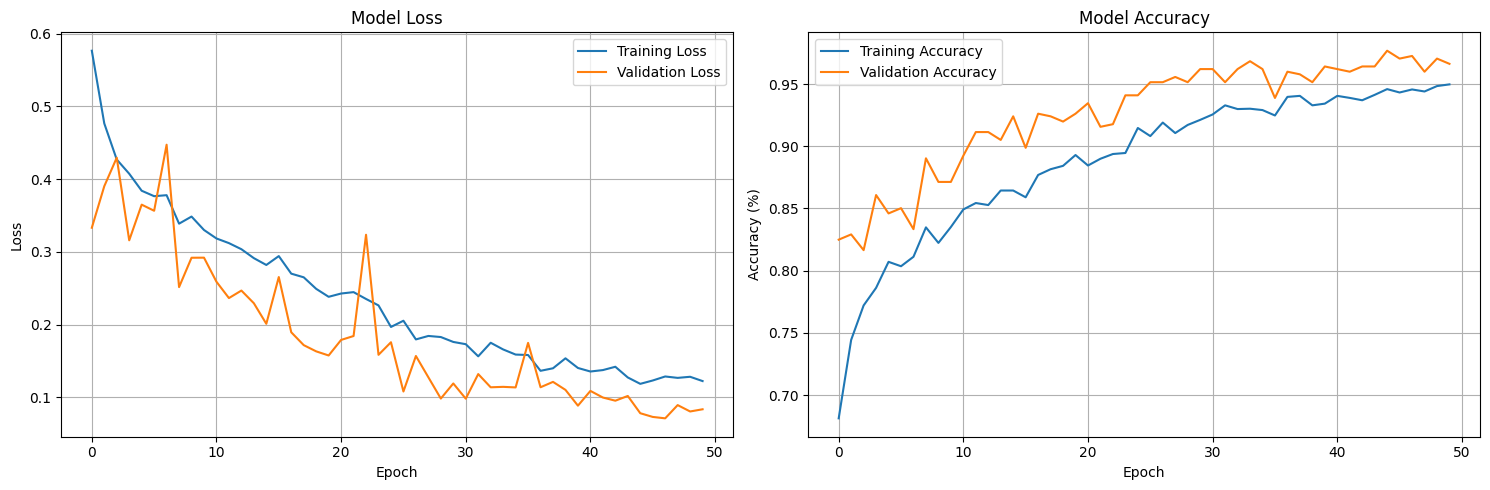

In [ ]:
def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(train_accuracies, label='Training Accuracy')
    ax2.plot(val_accuracies, label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history['train_loss'], history['val_loss'], history['train_acc'], history['val_acc'])

In [ ]:
# Load best model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EfficientNetLSTM(hidden_size=256, num_layers=2, dropout=0.5).to(device)
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
print("Model load thanh cong")

Model load thanh cong


Predict

In [ ]:
def predict_video(model, video_path, transform, device, num_frames=16, threshold=0.5):
    """
    Dự đoán video có Fall hay không

    Args:
        model: Model đã train
        video_path: Đường dẫn đến video
        transform: Transform để preprocess
        device: cuda/cpu
        num_frames: Số frame để extract
        threshold: Ngưỡng phân loại

    Returns:
        prediction: 'Fall' hoặc 'No_Fall'
        confidence: Độ tin cậy (0-1)
    """
    # Extract frames
    frames = extract_frame(video_path, num_frames)

    # Transform
    augmented_frames = transform(images=frames)['images']

    # Add batch dimension
    video_tensor = augmented_frames.unsqueeze(0).to(device)  # (1, num_frames, C, H, W)

    # Predict
    with torch.no_grad():
        output = model(video_tensor)
        probability = torch.sigmoid(output).item()

    # Classify
    prediction = 'Fall' if probability > threshold else 'No_Fall'
    confidence = probability if probability > 0.5 else (1 - probability)

    return prediction, confidence, probability

In [ ]:
# Test với 1 video
test_video_path = '/content/dataset-fall/split_dataset/test/No_Fall/Raw_Video/R0156.mp4'

prediction, confidence, prob = predict_video(
    model=model,
    video_path=test_video_path,
    transform=val_test_transform,
    device=device,
    num_frames=NUM_FRAMES
)

print(f"Video: {test_video_path}")
print(f"Prediction: {prediction}")
print(f"Confidence: {confidence:.2%}")
print(f"Fall Probability: {prob:.4f}")

Video: /content/dataset-fall/split_dataset/test/No_Fall/Raw_Video/R0156.mp4
Prediction: No_Fall
Confidence: 99.92%
Fall Probability: 0.0008


In [ ]:
# Test với 1 video
test_video_path = '/content/dataset-fall/split_dataset/test/Fall/Raw_Video/S_N_98_resized.mp4'

prediction, confidence, prob = predict_video(
    model=model,
    video_path=test_video_path,
    transform=val_test_transform,
    device=device,
    num_frames=NUM_FRAMES
)

print(f"Video: {test_video_path}")
print(f"Prediction: {prediction}")
print(f"Confidence: {confidence:.2%}")
print(f"Fall Probability: {prob:.4f}")

Video: /content/dataset-fall/split_dataset/test/Fall/Raw_Video/S_N_98_resized.mp4
Prediction: Fall
Confidence: 99.85%
Fall Probability: 0.9985


Testing: 100%|██████████| 57/57 [01:29<00:00,  1.57s/it]


TEST SET EVALUATION
Accuracy:  0.9465
Precision: 0.9746
Recall:    0.9100
F1-Score:  0.9412

Confusion Matrix:
[[233   5]
 [ 19 192]]


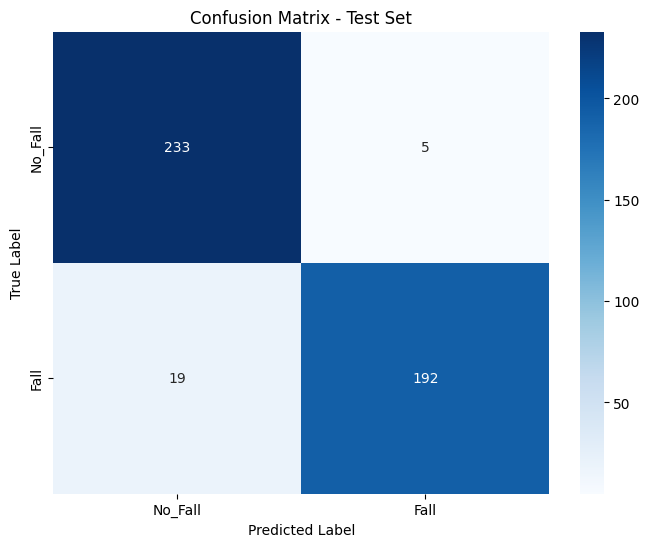

In [ ]:
def evaluate_test_set(model, test_loader, device):
    """Đánh giá trên test set"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(test_loader, desc="Testing"):
            videos = videos.to(device)
            labels = labels.float().to(device)

            outputs = model(videos)
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).float()

            # FIX: Đảm bảo là 1D tensor trước khi extend
            if predicted.dim() == 0:
                # Nếu là scalar (batch_size=1), wrap thành list
                all_preds.append(predicted.item())
                all_labels.append(labels.item())
                all_probs.append(probs.item())
            else:
                # Nếu là tensor 1D, convert sang list
                all_preds.extend(predicted.cpu().numpy().tolist())
                all_labels.extend(labels.cpu().numpy().tolist())
                all_probs.extend(probs.cpu().numpy().tolist())

    # Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    print("=" * 50)
    print("TEST SET EVALUATION")
    print("=" * 50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No_Fall', 'Fall'],
                yticklabels=['No_Fall', 'Fall'])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix - Test Set')
    plt.show()

    return accuracy, precision, recall, f1, cm

# Chạy evaluation
test_acc, test_prec, test_rec, test_f1, test_cm = evaluate_test_set(model, test_batch, device)